In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

import matplotlib.pyplot as plt
from utils import eval_basis_functions, get_coeff, single_stacked_kan_training

In [3]:
fn = lambda x: torch.exp(torch.sin(torch.pi * x[:, :1]) + torch.pow(x[:, 1:] + 0.5, 2))

x1 = torch.linspace(-1, 1, steps=40)
x2 = torch.linspace(-1, 1, steps=40)
x1, x2 = torch.meshgrid(x1, x2, indexing='ij')
x_eval = torch.stack([x1.flatten(), x2.flatten()], dim=1)
y_target = fn(x_eval) #+ torch.randn((x_eval.shape[0], 1))*0.1

# test and train split
n_training = int(x_eval.shape[0] * 0.8)
training_idxs = np.random.randint(x_eval.shape[0], size=n_training)
test_idxs = [i for i in range(x_eval.shape[0]) if i not in training_idxs]
x_training = x_eval[training_idxs]
x_test = x_eval[test_idxs]
y_training = y_target[training_idxs]
y_test = y_target[test_idxs]

print("Training dataset: ", n_training)
print("Test dataset: ", len(test_idxs))

Training dataset:  1280
Test dataset:  702


In [4]:
def initialize_KAN(KAN, k, grid_range, grid_size):
    """
    Returns the ingredients necessary to evaluate a KAN.
    Note: we use a single grid for all the activation functions.

    Args:
        KAN: List of integers corresponding to neurons in each layer
        k: spline order
        grid_range: range of grid. e.g, [-1, 1]
        grid_size: number of control points
    """
    grid = torch.linspace(grid_range[0], grid_range[1], steps=grid_size).unsqueeze(dim=0)

    # initialize the coefficients and symbolic functions
    coefs, masks, symbolic_functions = [], [], []
    for in_dim, out_dim in zip(KAN, KAN[1:]):
        coef = torch.zeros((in_dim, out_dim, grid_size + k - 1), requires_grad=True)
        mask = torch.ones((in_dim, out_dim))
        coefs.append(coef)
        masks.append(mask)

        symb_fns = [[lambda x:x for _ in range(out_dim)] for _ in range(in_dim)]
        symbolic_functions.append(symb_fns)

    return coefs, masks, symbolic_functions, grid

In [5]:
def eval_KAN(x, coefs, masks, symbolic_functions, grid, k):
    """
    Acts as the model.forward to evaluate x according to the given KAN.

    Args:
        x: Batch x input_dimensions
        coefs: list of coefficients of size (in_dim, out_dim, h), where in_dim and out_dim are determined by the KAN structure, h is determined by the grid
        masks: list of masks to be used to combine spline activation and symbolic activations. Each mask is (in_dim, out_dim). A value of 1 means use spline.
        symbolic_functions: list of list symbolic functions. Each inner list represents symbolic function corresponding to a specific input dimension.
        grid: grid for spline estimation
        k: order of spline
    """
    x_in = x
    for coef, mask, symb_fns in zip(coefs, masks, symbolic_functions):
        # spline activations
        bases = eval_basis_functions(x_in, grid, k)
        y_sp = torch.einsum('ijk, bik -> bij', coef, bases)

        # symbolic activations
        y_symb = eval_x_symbolically(x_in, symb_fns)

        # combine the two outputs
        y = mask[None, ...] * y_sp + (1-mask[None, ...]) * y_symb

        # add along the input dimensions
        x_in = y.sum(dim=1) # B x output_dimension

    return x_in



In [6]:
def eval_x_symbolically(x_eval, symbolic_fns):
    """
    Evaluates `x_eval` using functions specified in `symbolic_fns`.

    Args:
        x_eval: batch x number of dimensions
        symbolic_fns: list of list of symbolc functions.
    """
    in_dim = len(symbolic_fns)
    out_dim = len(symbolic_fns[0])
    postacts = []
    for i in range(in_dim):
        postacts_ = []
        for j in range(out_dim):
            symb_fn = symbolic_fns[i][j]
            postacts_.append(symb_fn(x_eval[:, i]))
        postacts.append(torch.stack(postacts_, dim=1))

    return torch.stack(postacts, dim=1) # stack so that the input_dim is intact

In [7]:
def set_symbolic_fn(symbolic_functions, masks, i, j, k, fn, use_affine=False):
    """
    Sets the symbolic function in the layer i, neuron j's kth output.

    Args:
         symbolic_functions:  list of list symbolic functions. Each inner list represents symbolic function corresponding to a specific input dimension.
         masks: list of masks to be used to combine spline activation and symbolic activations. Each mask is (in_dim, out_dim). A value of 1 means use spline.
         i: layer index
         j: neuron index (input)
         k: output index
         fn: function to use
         use_affine: whether to use SymbolicKANLayer or not

    Returns:
        modified symbolic_functions and masks
    """
    if use_affine:
        symb_fn = SymbolicKANLayer(fn)
    else:
        symb_fn = fn

    symbolic_functions[i][j][k] = symb_fn
    masks[i].data[j][k]= 0

    return symbolic_functions, masks

**Section 1: Training a KAN without symbolic formulae**

In [8]:
# KAN setup
k = 3
grid_range = [-1, 1]
grid_size = 10
KAN = [2, 1, 1]

coefs, masks, symbolic_functions, grid = initialize_KAN(KAN, k, grid_range, grid_size)

# training hyperparameters
lr = 0.01
early_stopping_iterations = 1e4
early_stopping_imrpovement_threshold = 200

losses = {'train': [], 'val': []}
i=0
verbose = True
best_loss = np.inf
while True:
    # randomly shuffle indices
    shuffled_idxs = torch.randperm(x_training.shape[0])
    y_pred = eval_KAN(x_training[shuffled_idxs], coefs, masks, symbolic_functions, grid, k)

    loss = torch.mean(torch.pow(y_pred - y_training[shuffled_idxs], 2))
    loss.backward()
    losses['train'].append(loss.item())

    for coef in coefs:
        if coef.grad is not None:
            coef.data = coef.data - lr * coef.grad
            coef.grad.zero_()


    with torch.no_grad():
        y_test_pred = eval_KAN(x_test, coefs, masks, symbolic_functions, grid, k)
        val_loss = torch.mean(torch.pow(y_test_pred - y_test, 2))

    losses['val'].append(val_loss.item())
    if i% 100 == 0 and verbose:
        print(f"Val loss: {val_loss.item(): 0.5f}\tTrain loss: {loss.item(): 0.5f}\tBest Val loss:{best_loss: 0.5f}")

    if best_loss > val_loss.item():
        best_loss = val_loss.item()
        best_model = (coefs, masks, symbolic_functions)
        n_no_improvements = 0
    else:
        n_no_improvements += 1
        if n_no_improvements > early_stopping_imrpovement_threshold:
            print('Stopping: No further improvements...')
            break

    i += 1
    if i > early_stopping_iterations:
        print('Stopping: Iteration limit reached...')
        break

Val loss:  24.60832	Train loss:  21.76396	Best Val loss: inf
Val loss:  10.55822	Train loss:  13.74281	Best Val loss: 10.42365
Val loss:  8.83116	Train loss:  6.69247	Best Val loss: 7.10991
Val loss:  11.34144	Train loss:  5.57517	Best Val loss: 5.47548
Val loss:  9.23391	Train loss:  3.73431	Best Val loss: 4.73521
Val loss:  3.89552	Train loss:  4.48644	Best Val loss: 3.84513
Val loss:  3.32734	Train loss:  2.67226	Best Val loss: 3.14750
Val loss:  3.42033	Train loss:  2.42059	Best Val loss: 2.82497
Val loss:  2.70580	Train loss:  3.43192	Best Val loss: 2.54278
Val loss:  5.04077	Train loss:  2.69733	Best Val loss: 2.15500
Val loss:  10.43574	Train loss:  4.85075	Best Val loss: 2.10940
Val loss:  3.90111	Train loss:  1.69826	Best Val loss: 1.97158
Val loss:  2.41973	Train loss:  3.05463	Best Val loss: 1.94094
Val loss:  5.04579	Train loss:  3.20785	Best Val loss: 1.82984
Val loss:  2.87750	Train loss:  2.51746	Best Val loss: 1.70806
Val loss:  3.32433	Train loss:  2.95560	Best Val los

validation loss:  1.54645


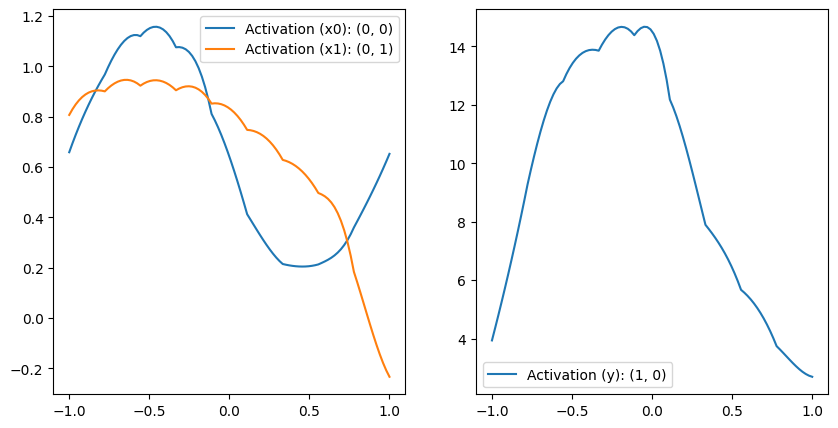

In [9]:
coefs, masks, symbolic_functions = best_model
print(f"validation loss: {best_loss: 0.5f}")

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 5), dpi=100)

x = torch.linspace(-1, 1, steps=100).unsqueeze(dim=1)
bases = eval_basis_functions(x, grid, k=3)

ax = axs[0]
y_out_0 = torch.einsum('ijk, bij->bk', coefs[0][0:1].transpose(2, 1), bases)
y_out_1 = torch.einsum('ijk, bij->bk', coefs[0][1:2].transpose(2, 1), bases)
ax.plot(x.numpy(), y_out_0.detach().numpy(), label="Activation (x0): (0, 0)")
ax.plot(x.numpy(), y_out_1.detach().numpy(), label="Activation (x1): (0, 1)")
ax.legend()

ax = axs[1]
y_out_final = torch.einsum('ijk, bij->bk', coefs[1].transpose(2, 1), bases)
ax.plot(x.numpy(), y_out_final.detach().numpy(), label="Activation (y): (1, 0)")

ax.legend()

**Section 2: Training KANs with activation fixed to identified Symbolic formulaSection 2: Training KANs with activation fixed to identified Symbolic formula**

In [10]:
class SymbolicKANLayer(nn.Module):
    def __init__(self, fn):
        super().__init__()
        self.fn = fn

        # learnable parameters
        self.affine = torch.nn.Parameter(torch.zeros(4), requires_grad=True)

    def forward(self, x_eval):
        return self.affine[0] * self.fn(self.affine[1]*x_eval + self.affine[2]) + self.affine[3]

    def step(self, lr):
        """
        Performs a step of gradient descent using the learning rate `lr`
        """
        if self.affine.grad is not None:
            self.affine.data = self.affine.data - lr * self.affine.grad

    def zero_grad_(self):
        """
        Zeroes out the gradients in-place.
        """
        self.affine.grad.zero_()

In [11]:
# KAN setup
k = 3
grid_range = [-1, 1]
grid_size = 10
KAN = [2, 1, 1]

coefs, masks, symbolic_functions, grid = initialize_KAN(KAN, k, grid_range, grid_size)

# training hyperparameters
lr = 0.01
early_stopping_iterations = 1e4
early_stopping_imrpovement_threshold = 200

# setup the symbolic forms
# A few candidate options
# symbolic_functions, masks = set_symbolic_fn(symbolic_functions, masks, 0, 0, 0, lambda x: torch.sin(torch.pi * x), use_affine=False)
# symbolic_functions, masks = set_symbolic_fn(symbolic_functions, masks, 0, 0, 0, lambda x: torch.sin(x), use_affine=True)
# symbolic_functions, masks = set_symbolic_fn(symbolic_functions, masks, 0, 1, 0, lambda x: torch.pow(x, 2), use_affine=True)
symbolic_functions, masks = set_symbolic_fn(symbolic_functions, masks, 0, 1, 0, lambda x: torch.pow(x + 0.5, 2), use_affine=False)
# symbolic_functions, masks = set_symbolic_fn(symbolic_functions, masks, 1, 0, 0, lambda x: torch.exp(x), use_affine=False)


losses_symb = {'train': [], 'val': []}
i=0
verbose = True
best_loss = np.inf
while True:
    # randomly shuffle indices
    shuffled_idxs = torch.randperm(x_training.shape[0])
    x = x_training[shuffled_idxs]
    y_pred = eval_KAN(x_training[shuffled_idxs], coefs, masks, symbolic_functions, grid, k)
    loss = torch.mean(torch.pow(y_pred - y_training[shuffled_idxs], 2))
    loss.backward()
    losses_symb['train'].append(loss.item())

    # backpropagate
    for coef in coefs:
        if coef.grad is not None:
            coef.data = coef.data - lr * coef.grad
            coef.grad.zero_()

    for symb_layer in symbolic_functions:
        for neuron in symb_layer:
            for out_symb in neuron:
                if isinstance(out_symb, SymbolicKANLayer):
                    out_symb.step(lr)
                    out_symb.zero_grad_()

    with torch.no_grad():
        y_test_pred = eval_KAN(x_test, coefs, masks, symbolic_functions, grid, k)
        val_loss = torch.mean(torch.pow(y_test_pred - y_test, 2))

    losses_symb['val'].append(val_loss.item())

    if i% 100 == 0 and verbose:
        print(f"Val loss: {val_loss.item(): 0.5f}\tTrain loss: {loss.item(): 0.5f}\tBest Val loss:{best_loss: 0.5f}")

    if best_loss > val_loss.item():
        best_loss = val_loss.item()
        best_model = (coefs, masks, symbolic_functions)
        n_no_improvements = 0
    else:
        n_no_improvements += 1
        if n_no_improvements > early_stopping_imrpovement_threshold:
            print('Stopping: No further improvements...')
            break

    i += 1
    if i > early_stopping_iterations:
        print('Stopping: Iteration limit reached...')
        break

Val loss:  26.04625	Train loss:  21.76396	Best Val loss: inf
Val loss:  20.98693	Train loss:  16.46554	Best Val loss: 21.06432
Val loss:  11.32405	Train loss:  8.57250	Best Val loss: 11.34220
Val loss:  7.60551	Train loss:  5.46178	Best Val loss: 7.68914
Val loss:  5.89709	Train loss:  4.34294	Best Val loss: 5.48087
Val loss:  4.57609	Train loss:  3.16482	Best Val loss: 4.17197
Val loss:  3.73081	Train loss:  2.25368	Best Val loss: 3.26232
Val loss:  3.20926	Train loss:  1.70262	Best Val loss: 2.63302
Val loss:  2.73203	Train loss:  1.37765	Best Val loss: 2.19642
Val loss:  2.23217	Train loss:  1.10813	Best Val loss: 1.89390
Val loss:  1.90463	Train loss:  0.94081	Best Val loss: 1.62574
Val loss:  1.81765	Train loss:  0.85268	Best Val loss: 1.41754
Val loss:  1.62359	Train loss:  0.75951	Best Val loss: 1.27832
Val loss:  1.46162	Train loss:  0.69303	Best Val loss: 1.17395
Val loss:  1.31795	Train loss:  0.63369	Best Val loss: 1.08314
Val loss:  1.12946	Train loss:  0.58323	Best Val los

validation loss:  0.60704


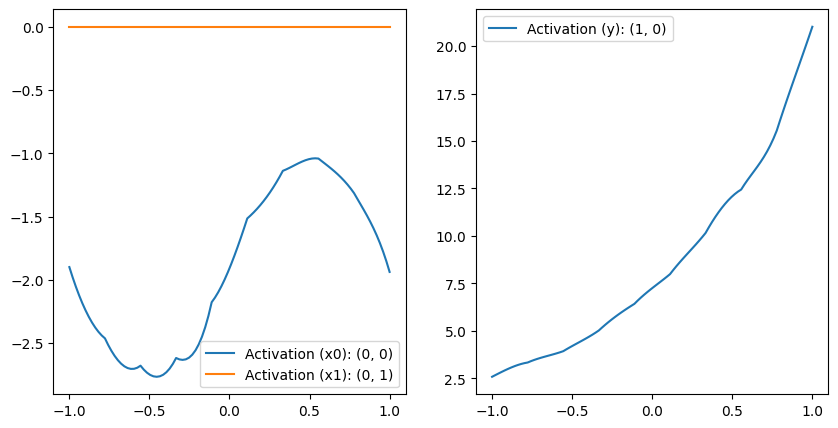

In [12]:
coefs, masks, symbolic_functions = best_model
print(f"validation loss: {best_loss: 0.5f}")

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 5), dpi=100)

x = torch.linspace(-1, 1, steps=100).unsqueeze(dim=1)
bases = eval_basis_functions(x, grid, k=3)

ax = axs[0]
y_out_0 = torch.einsum('ijk, bij->bk', coefs[0][0:1].transpose(2, 1), bases)
y_out_1 = torch.einsum('ijk, bij->bk', coefs[0][1:2].transpose(2, 1), bases)
ax.plot(x.numpy(), y_out_0.detach().numpy(), label="Activation (x0): (0, 0)")
ax.plot(x.numpy(), y_out_1.detach().numpy(), label="Activation (x1): (0, 1)")
ax.legend()

ax = axs[1]
y_out_final = torch.einsum('ijk, bij->bk', coefs[1].transpose(2, 1), bases)
ax.plot(x.numpy(), y_out_final.detach().numpy(), label="Activation (y): (1, 0)")

ax.legend()

Text(0.5, 1.0, 'Loss')

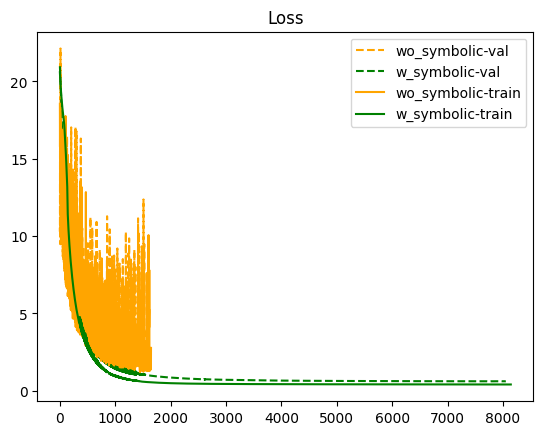

In [13]:
plt.plot(losses['val'][100:], label='wo_symbolic-val', linestyle='--', alpha=1.0, color='orange')
plt.plot(losses_symb['val'][100:], label='w_symbolic-val', linestyle='--', alpha=1.0,  color='green')

plt.plot(losses['train'][10:], label='wo_symbolic-train', linestyle='-', alpha=1.0, color='orange')
plt.plot(losses_symb['train'][10:], label='w_symbolic-train', linestyle='-', alpha=1.0,  color='green')

# plt.ylim(0,1)
plt.legend()
plt.title('Loss')